In [1]:
%%writefile /home/afzal/projects/knee-oa-classification/src/predict.py
"""Final inference pipeline: preprocess -> ensemble of two custom CNNs -> prior-adjusted decision.

Frozen before test-set evaluation. Members and decision rule chosen on validation data only.
"""
from pathlib import Path

import keras
import numpy as np

import data
import preprocessing as pp

PROJECT = Path.home() / "projects/knee-oa-classification"
MODELS = PROJECT / "models"
MEMBERS = ["exp1_augmentation", "exp3_aug_wider"]

TRAIN_COUNTS = np.array([2286, 1046, 1516, 757, 173])      # training images per KL grade
TRAIN_PRIOR = TRAIN_COUNTS / TRAIN_COUNTS.sum()


class KneeOAPipeline:
    def __init__(self, members=MEMBERS):
        self.members = list(members)
        self.models = [keras.models.load_model(MODELS / f"{m}.keras") for m in self.members]

    def predict_proba(self, X):
        """X: preprocessed uint8 images, shape (N, 224, 224). Returns averaged softmax (N, 5)."""
        ds = data.make_dataset(X, np.zeros(len(X), dtype=np.int64), batch_size=64)
        return np.mean([m.predict(ds, verbose=0) for m in self.models], axis=0)

    def predict(self, X, prior_adjust=True):
        p = self.predict_proba(X)
        return (p / TRAIN_PRIOR).argmax(axis=1) if prior_adjust else p.argmax(axis=1)

    def predict_image(self, path):
        """Full pipeline for one raw X-ray file: preprocess, predict, return grade + probabilities."""
        img = pp.load_and_preprocess(path)
        p = self.predict_proba(img[None])[0]
        adjusted = p / TRAIN_PRIOR
        return {"kl_grade": int(adjusted.argmax()),
                "model_probabilities": {g: round(float(v), 4) for g, v in enumerate(p)},
                "adjusted_scores": {g: round(float(v), 4) for g, v in enumerate(adjusted / adjusted.sum())}}

Writing /home/afzal/projects/knee-oa-classification/src/predict.py


In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT = Path.home() / "projects/knee-oa-classification"
sys.path.insert(0, str(PROJECT / "src"))

import data
import evaluation as ev
from predict import KneeOAPipeline

pipe = KneeOAPipeline()
X_val, y_val = data.load_split("val")
m_val = ev.compute_metrics(y_val, pipe.predict(X_val))
print(f"Frozen pipeline on validation: balanced accuracy {m_val['balanced_accuracy']:.4f} "
      f"(expect 0.6467) | QWK {m_val['qwk']:.4f}")

I0000 00:00:1791134671.269579   24263 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791134671.303759   24263 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791134672.643351   24263 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791134674.577577   24263 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB mem

Frozen pipeline on validation: balanced accuracy 0.6467 (expect 0.6467) | QWK 0.7115


Test set: 1656 images | per grade [639 296 447 223  51]

Balanced accuracy: 0.6437 | Accuracy: 0.5417 | QWK: 0.7533 | Macro F1: 0.6036

              precision    recall  f1-score   support

           0      0.803     0.440     0.568       639
           1      0.237     0.436     0.307       296
           2      0.589     0.579     0.584       447
           3      0.713     0.803     0.755       223
           4      0.690     0.961     0.803        51

    accuracy                          0.542      1656
   macro avg      0.606     0.644     0.604      1656
weighted avg      0.628     0.542     0.558      1656



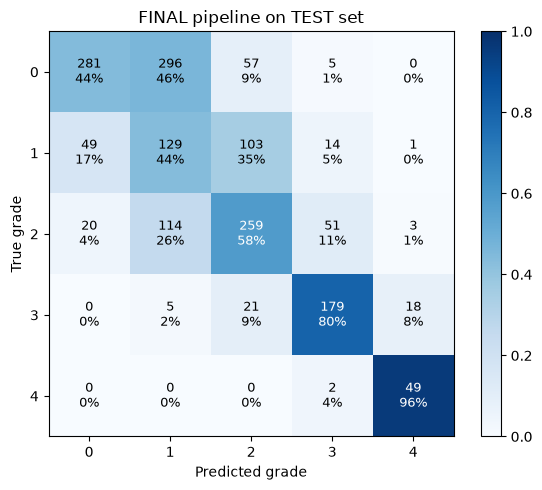


final (prior-adjusted)   bal_acc 0.644 [0.621, 0.666] | QWK 0.753 [0.730, 0.775] | recalls 0.44 / 0.44 / 0.58 / 0.80 / 0.96
secondary (argmax)       bal_acc 0.646 [0.621, 0.668] | QWK 0.756 [0.729, 0.780] | recalls 0.82 / 0.02 / 0.72 / 0.78 / 0.88
Validation reference (final pipeline): bal_acc 0.647 | QWK 0.711


In [3]:
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score

X_test, y_test = data.load_split("test")
print(f"Test set: {len(y_test)} images | per grade {np.bincount(y_test)}\n")

def bootstrap_ci(y_true, y_pred, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    ba, qwk = [], []
    for _ in range(n_boot):
        s = rng.integers(0, n, n)
        ba.append(balanced_accuracy_score(y_true[s], y_pred[s]))
        qwk.append(cohen_kappa_score(y_true[s], y_pred[s], weights="quadratic"))
    return np.percentile(ba, [2.5, 97.5]), np.percentile(qwk, [2.5, 97.5])

p_test = pipe.predict_proba(X_test)
decisions = {
    "final (prior-adjusted)": (p_test / pipe_prior).argmax(axis=1) if (pipe_prior := __import__("predict").TRAIN_PRIOR) is not None else None,
    "secondary (argmax)": p_test.argmax(axis=1),
}

# --- Primary result: full report ---
y_final = decisions["final (prior-adjusted)"]
m_test = ev.evaluate_predictions(y_test, y_final, title="FINAL pipeline on TEST set",
                                 save_path=PROJECT / "reports/cm_final_test.png")
ev.log_run("FINAL_ensemble_prior_adj", {"members": ["exp1_augmentation", "exp3_aug_wider"],
                                        "decision": "argmax(p / train_prior)"},
           m_test, split="test")

# --- Summary with confidence intervals, both decision rules ---
print("\n" + "=" * 92)
for name, pred in decisions.items():
    m = ev.compute_metrics(y_test, pred)
    (ba_lo, ba_hi), (q_lo, q_hi) = bootstrap_ci(y_test, pred)
    recalls = " / ".join(f"{m[f'recall_g{g}']:.2f}" for g in range(5))
    print(f"{name:24s} bal_acc {m['balanced_accuracy']:.3f} [{ba_lo:.3f}, {ba_hi:.3f}] | "
          f"QWK {m['qwk']:.3f} [{q_lo:.3f}, {q_hi:.3f}] | recalls {recalls}")
print("=" * 92)
print(f"Validation reference (final pipeline): bal_acc {m_val['balanced_accuracy']:.3f} | QWK {m_val['qwk']:.3f}")

In [7]:
%%writefile /home/afzal/projects/knee-oa-classification/src/gradcam.py
"""Explainability: Grad-CAM (single, multi-layer, ensemble), occlusion sensitivity, deletion test."""
import cv2
import keras
import numpy as np
import tensorflow as tf


def make_gradcam_model(model, layer_name="block4_relu2"):
    """Model returning (feature maps of layer_name, predictions)."""
    return keras.Model(model.inputs, [model.get_layer(layer_name).output, model.output])


def gradcam(grad_model, img_uint8, class_idx=None):
    """Heatmap (224x224, values 0-1) of evidence for class_idx in one preprocessed image."""
    x = tf.convert_to_tensor(img_uint8[None, ..., None].astype("float32") / 255.0)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x, training=False)
        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))
        score = preds[:, class_idx]
    grads = tape.gradient(score, conv_out)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.nn.relu(tf.reduce_sum(conv_out * weights[:, None, None, :], axis=-1))[0].numpy()
    cam = cv2.resize(cam, (img_uint8.shape[1], img_uint8.shape[0]))
    return (cam / cam.max() if cam.max() > 0 else cam), class_idx


def build_gradcam_models(models, layers=("block3_relu2", "block4_relu2")):
    """One Grad-CAM model per (network, layer) pair."""
    return [make_gradcam_model(m, layer) for m in models for layer in layers]


def ensemble_gradcam(grad_models, img_uint8, class_idx):
    """Average of normalised Grad-CAM maps across networks and layers."""
    cams = [gradcam(gm, img_uint8, class_idx)[0] for gm in grad_models]
    cam = np.mean(cams, axis=0)
    return cam / cam.max() if cam.max() > 0 else cam


def occlusion_map(predict_fn, img_uint8, class_idx, patch=24, stride=8):
    """Confidence drop for class_idx when each patch is hidden. predict_fn: uint8 (N,224,224) -> probs."""
    H, W = img_uint8.shape
    fill = np.uint8(img_uint8.mean())
    base = predict_fn(img_uint8[None])[0, class_idx]
    coords = [(y, x) for y in range(0, H - patch + 1, stride) for x in range(0, W - patch + 1, stride)]
    batch = np.repeat(img_uint8[None], len(coords), axis=0)
    for k, (y, x) in enumerate(coords):
        batch[k, y:y + patch, x:x + patch] = fill
    drops = base - predict_fn(batch)[:, class_idx]
    heat, count = np.zeros((H, W)), np.zeros((H, W))
    for d, (y, x) in zip(drops, coords):
        heat[y:y + patch, x:x + patch] += d
        count[y:y + patch, x:x + patch] += 1
    heat = np.maximum(heat / np.maximum(count, 1), 0)
    return heat / heat.max() if heat.max() > 0 else heat


def random_blob_map(rng, shape=(224, 224), grid=7):
    """Smooth random 'explanation' used as a baseline in the deletion test."""
    return cv2.resize(rng.random((grid, grid)).astype("float32"), (shape[1], shape[0]))


def deletion_curve(predict_fn, img_uint8, saliency, class_idx, fractions=np.linspace(0, 0.5, 11)):
    """Confidence in class_idx as the top-ranked fraction of pixels is erased."""
    order = np.argsort(saliency.ravel())[::-1]
    fill = np.uint8(img_uint8.mean())
    batch = []
    for f in fractions:
        x = img_uint8.copy().ravel()
        x[order[:int(f * x.size)]] = fill
        batch.append(x.reshape(img_uint8.shape))
    return predict_fn(np.stack(batch))[:, class_idx]


def overlay(img_uint8, cam, alpha=0.4):
    """Blend a jet-coloured heatmap over the grayscale X-ray."""
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)[..., ::-1]
    base = np.repeat(img_uint8[..., None], 3, axis=-1)
    return np.uint8((1 - alpha) * base + alpha * heat)

Overwriting /home/afzal/projects/knee-oa-classification/src/gradcam.py


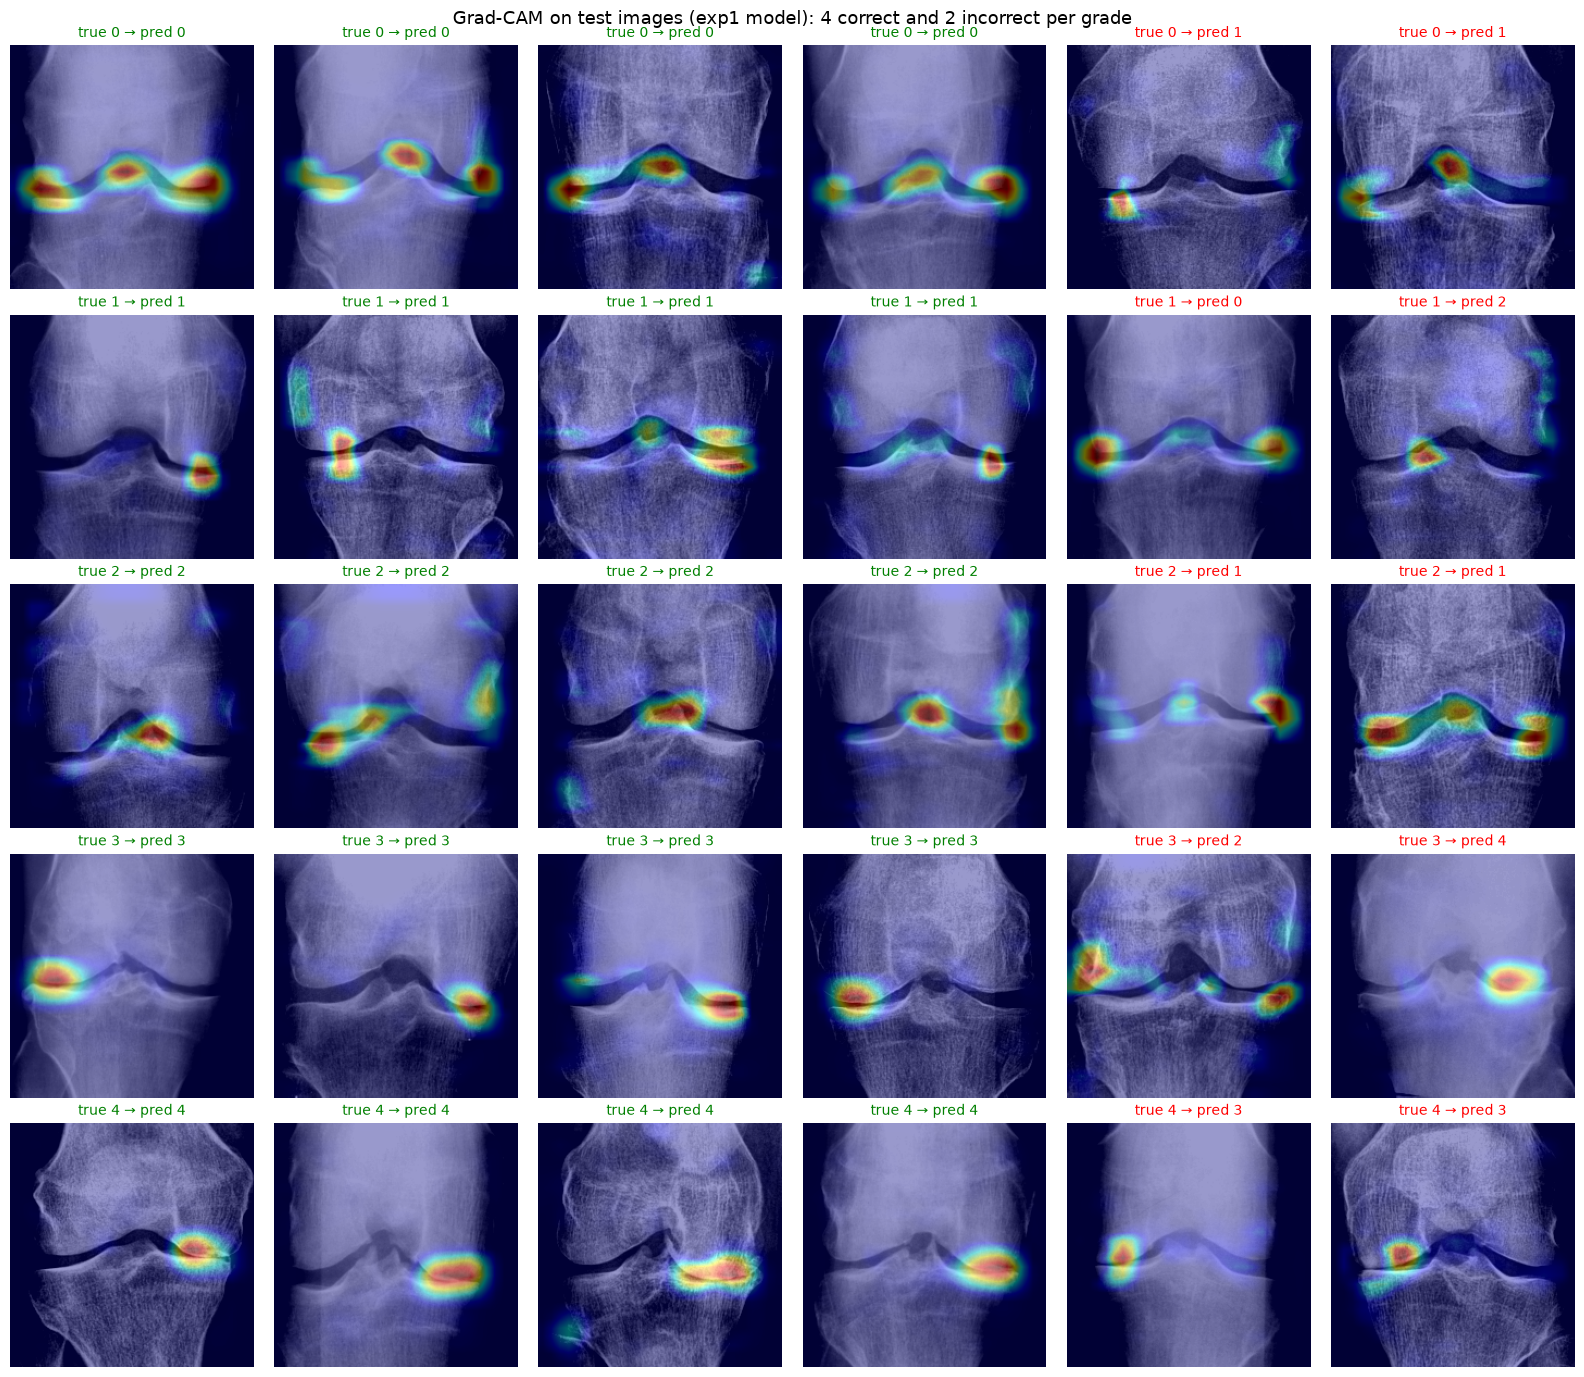

In [5]:
import matplotlib.pyplot as plt
import gradcam as gc

gm1 = gc.make_gradcam_model(pipe.models[0])          # exp1_augmentation
rng = np.random.default_rng(1)

fig, axes = plt.subplots(5, 6, figsize=(16, 14))
for g in range(5):
    correct = np.where((y_test == g) & (y_final == g))[0]
    wrong = np.where((y_test == g) & (y_final != g))[0]
    picks = list(rng.choice(correct, 4, replace=False)) + list(rng.choice(wrong, min(2, len(wrong)), replace=False))
    for j in range(6):
        ax = axes[g, j]; ax.axis("off")
        if j >= len(picks):
            continue
        i = picks[j]
        cam, _ = gc.gradcam(gm1, X_test[i], class_idx=int(y_final[i]))
        ax.imshow(gc.overlay(X_test[i], cam))
        ax.set_title(f"true {g} → pred {y_final[i]}", fontsize=10,
                     color="green" if y_final[i] == g else "red")
plt.suptitle("Grad-CAM on test images (exp1 model): 4 correct and 2 incorrect per grade", fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT / "reports/gradcam_test_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
mask = np.zeros((224, 224), dtype=bool)
mask[70:154, 20:204] = True                           # approximate joint band

idx = rng.choice(len(y_test), 300, replace=False)
inside = []
for i in idx:
    cam, _ = gc.gradcam(gm1, X_test[i], class_idx=int(y_final[i]))
    inside.append(cam[mask].sum() / max(cam.sum(), 1e-8))

print(f"The joint band covers {mask.mean():.0%} of each image, "
      f"but holds {np.mean(inside):.0%} of the Grad-CAM signal on average "
      f"(median {np.median(inside):.0%}, over {len(idx)} test images).")

The joint band covers 31% of each image, but holds 73% of the Grad-CAM signal on average (median 75%, over 300 test images).


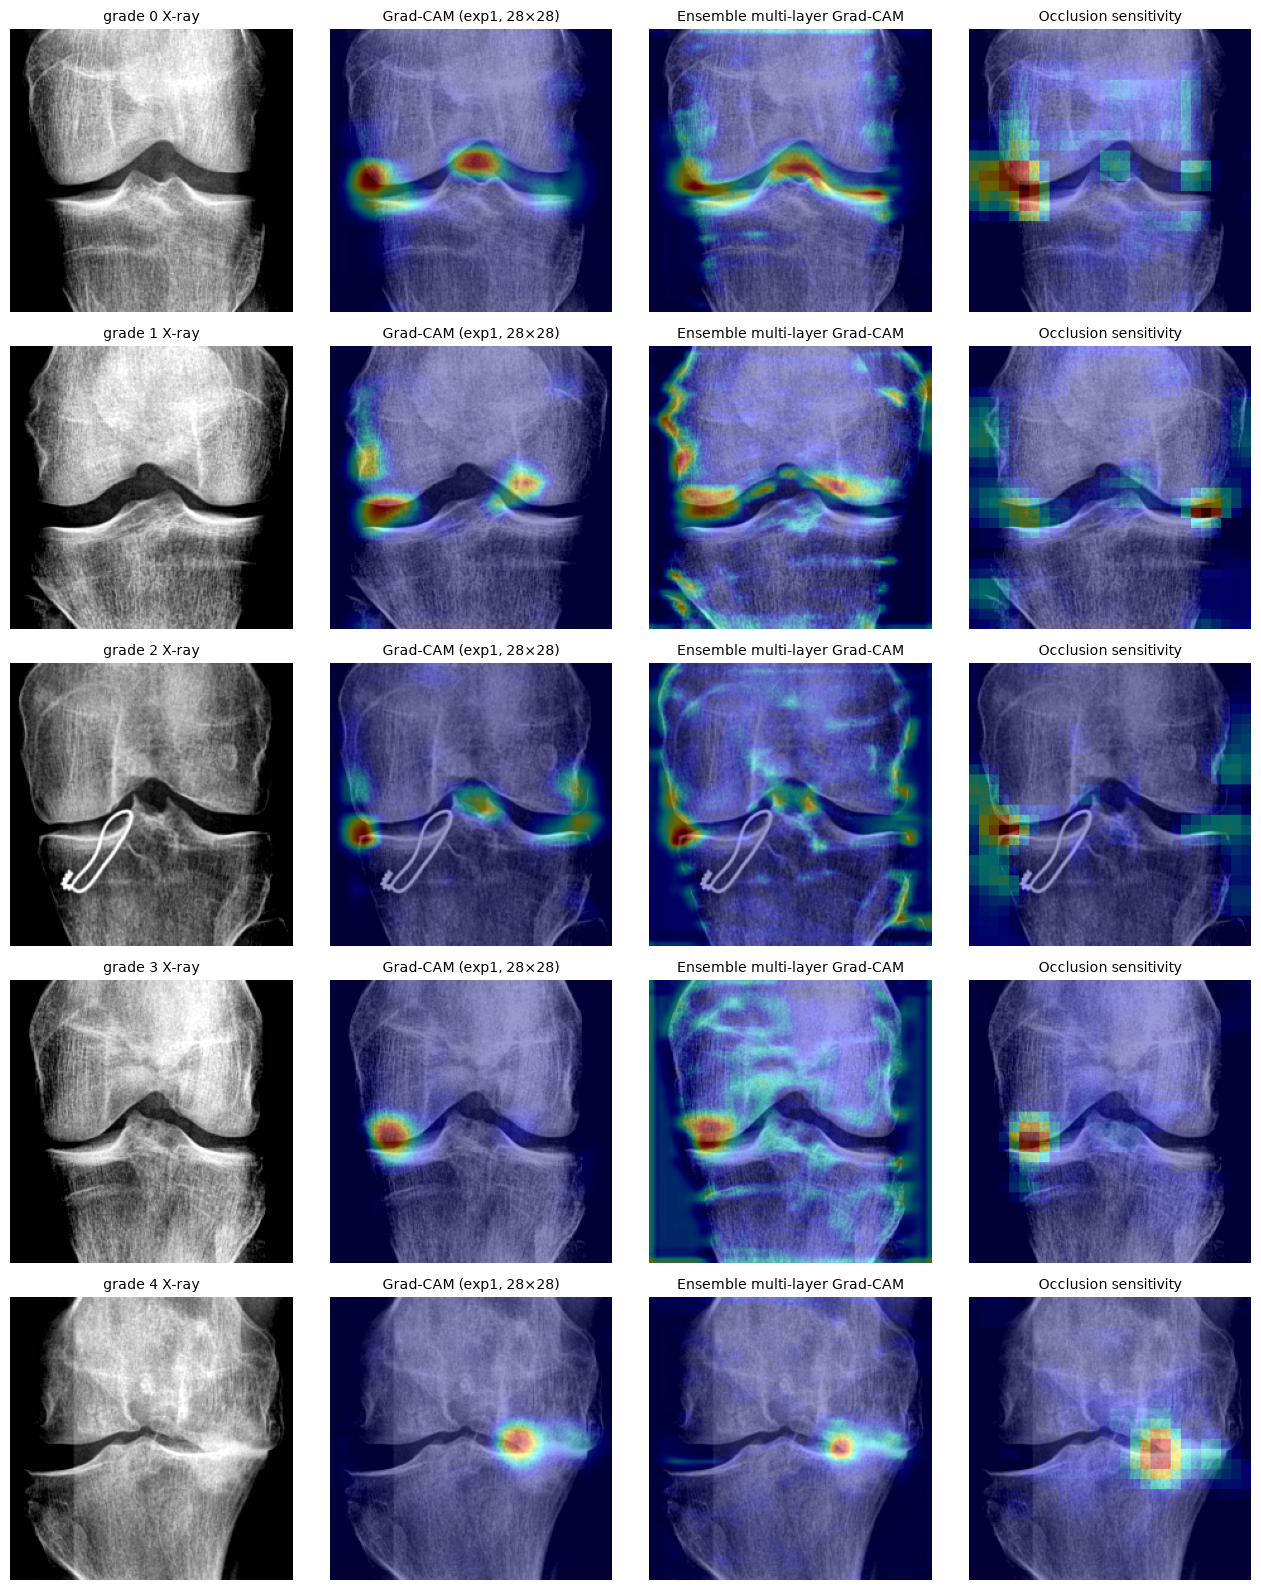

In [8]:
grad_models = gc.build_gradcam_models(pipe.models)          # exp1 + exp3, two layers each
predict_fn = pipe.predict_proba

rng = np.random.default_rng(7)
picks = [rng.choice(np.where((y_test == g) & (y_final == g))[0]) for g in range(5)]

fig, axes = plt.subplots(5, 4, figsize=(13, 16))
for row, i in enumerate(picks):
    c = int(y_final[i])
    maps = [None,
            gc.gradcam(gm1, X_test[i], c)[0],
            gc.ensemble_gradcam(grad_models, X_test[i], c),
            gc.occlusion_map(predict_fn, X_test[i], c)]
    titles = [f"grade {y_test[i]} X-ray", "Grad-CAM (exp1, 28×28)",
              "Ensemble multi-layer Grad-CAM", "Occlusion sensitivity"]
    for col, (mp, t) in enumerate(zip(maps, titles)):
        ax = axes[row, col]
        ax.imshow(X_test[i] if mp is None else gc.overlay(X_test[i], mp),
                  cmap="gray" if mp is None else None)
        ax.set_title(t, fontsize=10); ax.axis("off")
plt.tight_layout()
plt.savefig(PROJECT / "reports/explanations_compared.png", dpi=150, bbox_inches="tight")
plt.show()

25/100 images done
50/100 images done
75/100 images done
100/100 images done


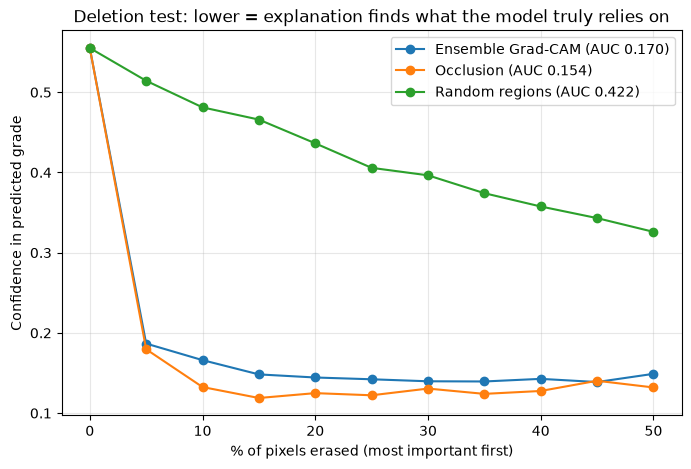

In [9]:
fractions = np.linspace(0, 0.5, 11)
idx = rng.choice(len(y_test), 100, replace=False)
curves = {"Ensemble Grad-CAM": [], "Occlusion": [], "Random regions": []}

for n, i in enumerate(idx):
    c = int(y_final[i])
    sal = {"Ensemble Grad-CAM": gc.ensemble_gradcam(grad_models, X_test[i], c),
           "Occlusion": gc.occlusion_map(predict_fn, X_test[i], c),
           "Random regions": gc.random_blob_map(rng)}
    for name, s in sal.items():
        curves[name].append(gc.deletion_curve(predict_fn, X_test[i], s, c, fractions))
    if (n + 1) % 25 == 0:
        print(f"{n + 1}/100 images done")

plt.figure(figsize=(8, 5))
for name, cs in curves.items():
    mean = np.mean(cs, axis=0)
    auc = np.trapezoid(mean, fractions) / fractions[-1]
    plt.plot(fractions * 100, mean, marker="o", label=f"{name} (AUC {auc:.3f})")
plt.xlabel("% of pixels erased (most important first)")
plt.ylabel("Confidence in predicted grade")
plt.title("Deletion test: lower = explanation finds what the model truly relies on")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(PROJECT / "reports/deletion_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
import keras
from scipy.stats import spearmanr

random_model = keras.models.clone_model(pipe.models[0])     # same architecture, fresh random weights
gm_random = gc.make_gradcam_model(random_model)

corrs, inside = [], []
for i in idx[:50]:
    c = int(y_final[i])
    cam_trained = gc.gradcam(gm1, X_test[i], c)[0]
    cam_random = gc.gradcam(gm_random, X_test[i], c)[0]
    corrs.append(spearmanr(cam_trained.ravel(), cam_random.ravel())[0])
    cam_ens = gc.ensemble_gradcam(grad_models, X_test[i], c)
    inside.append(cam_ens[mask].sum() / max(cam_ens.sum(), 1e-8))

print(f"Sanity check: similarity between trained and random-weight Grad-CAM "
      f"(Spearman): mean {np.nanmean(corrs):.2f}  (near 0 = PASS, near 1 = FAIL)")
print(f"Ensemble multi-layer Grad-CAM: {np.mean(inside):.0%} of signal in the joint band "
      f"(31% of area), vs 73% for exp1 alone")

Sanity check: similarity between trained and random-weight Grad-CAM (Spearman): mean -0.03  (near 0 = PASS, near 1 = FAIL)
Ensemble multi-layer Grad-CAM: 51% of signal in the joint band (31% of area), vs 73% for exp1 alone
